In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
data=pd.read_csv('titanic_data.csv')

In [62]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          713 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     887 non-null    object 
 8   class        889 non-null    object 
 9   who          889 non-null    object 
 10  adult_male   889 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  887 non-null    object 
 13  alive        889 non-null    object 
 14  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.2+ KB


In [64]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,176
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [65]:
data.dropna(inplace=True)

In [66]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 887
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     182 non-null    int64  
 1   pclass       182 non-null    int64  
 2   sex          182 non-null    object 
 3   age          182 non-null    float64
 4   sibsp        182 non-null    int64  
 5   parch        182 non-null    int64  
 6   fare         182 non-null    float64
 7   embarked     182 non-null    object 
 8   class        182 non-null    object 
 9   who          182 non-null    object 
 10  adult_male   182 non-null    bool   
 11  deck         182 non-null    object 
 12  embark_town  182 non-null    object 
 13  alive        182 non-null    object 
 14  alone        182 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 20.3+ KB


In [68]:
data.drop_duplicates(inplace=True)

In [69]:
q1=data['age'].quantile(0.25)

q3=data['age'].quantile(0.75)

iqr=q3-q1

lower_limit=q1-1.5*(q3-q1)

upper_limit=q3+1.5*(q3-q1)

data=data[(data['age']>=lower_limit) & (data['age']<=upper_limit)]

In [70]:
x=data.drop('survived',axis=1)
y=data['survived']

In [71]:
quant=[]
cat=[]
for i in x.columns:
    if x[i].nunique()>15:
        quant.append(i)
    else:
        cat.append(i)


In [72]:
print(quant)
print(cat)

['age', 'fare']
['pclass', 'sex', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [73]:
x[cat]

,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,female,1,0,C,First,woman,False,C,Cherbourg,yes,False
3,1,female,1,0,S,First,woman,False,C,Southampton,yes,False
6,1,male,0,0,S,First,man,True,E,Southampton,no,True
10,3,female,1,1,S,Third,child,False,G,Southampton,yes,False
11,1,female,0,0,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...
869,1,female,1,1,S,First,woman,False,D,Southampton,yes,False
870,1,male,0,0,S,First,man,True,B,Southampton,no,True
877,1,female,0,1,C,First,woman,False,C,Cherbourg,yes,False
885,1,female,0,0,S,First,woman,False,B,Southampton,yes,True


In [74]:
#label encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat:
    x[i]=le.fit_transform(x[i])

In [75]:
x[cat]

,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,0,0,1,0,0,0,2,0,2,0,1,0
3,0,0,1,0,2,0,2,0,2,2,1,0
6,0,1,0,0,2,0,1,1,4,2,0,1
10,2,0,1,1,2,2,0,0,6,2,1,0
11,0,0,0,0,2,0,2,0,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
869,0,0,1,1,2,0,2,0,3,2,1,0
870,0,1,0,0,2,0,1,1,1,2,0,1
877,0,0,0,1,0,0,2,0,2,0,1,0
885,0,0,0,0,2,0,2,0,1,2,1,1


In [76]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
x[quant]=mm.fit_transform(x[quant])

In [77]:
data[quant]

,age,fare
1,38.0,71.2833
3,35.0,53.1000
6,54.0,51.8625
10,4.0,16.7000
11,58.0,26.5500
...,...,...
869,47.0,52.5542
870,33.0,5.0000
877,56.0,83.1583
885,19.0,30.0000


In [78]:
y


,survived
1,1
3,1
6,0
10,1
11,1
...,...
869,1
870,0
877,1
885,1


In [79]:
data=x.copy()
data['survived']=y

<Axes: >

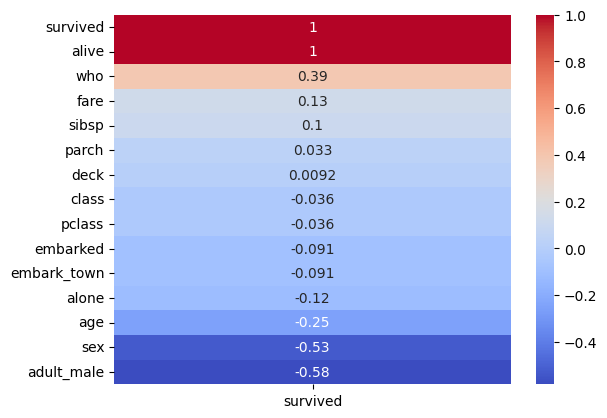

In [80]:
import seaborn as sns
corr=data.corr()
labeled_corr=corr[['survived']].sort_values(by='survived',ascending=False)
sns.heatmap(labeled_corr,annot=True,cmap='coolwarm')

In [81]:
x.drop('deck',axis=1)

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,0,0,0.468892,1,0,0.139136,0,0,2,0,0,1,0
3,0,0,0.430956,1,0,0.103644,2,0,2,0,2,1,0
6,0,1,0.671219,0,0,0.101229,2,0,1,1,2,0,1
10,2,0,0.038948,1,1,0.032596,2,2,0,0,2,1,0
11,0,0,0.721801,0,0,0.051822,2,0,2,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,0,0,0.582701,1,1,0.102579,2,0,2,0,2,1,0
870,0,1,0.405665,0,0,0.009759,2,0,1,1,2,0,1
877,0,0,0.696510,0,1,0.162314,0,0,2,0,0,1,0
885,0,0,0.228629,0,0,0.058556,2,0,2,0,2,1,1


In [82]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score,confusion_matrix,classification_report
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



1.0
[[14  0]
 [ 0 23]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        23

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

